In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, accuracy_score, f1_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import pickle
import joblib
import os
import matplotlib.pyplot as plt

In [4]:
# Binary classifier
# data = combined, same as the regression model but with the binary label?
df_binary = pd.read_parquet("../0_data/processed_data/data_with_selected_features_LGB_All_scaled_binary.parquet")
df_train = df_binary[df_binary['Type'] == 'Train'].reset_index(drop=True)

df_train

,SMILES,MP,Type,MP_label,RDKit_FpDensityMorgan3,RDKit_TPSA,RDKit_NumRotatableBonds,RDKit_SMR_VSA10,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_MRLOW,...,RDKit_Chi2n,RDKit_SlogP_VSA3,RDKit_fr_Ar_NH,RDKit_EState_VSA4,MACCS_89,RDKit_SMR_VSA9,MACCS_131,RDKit_fr_imidazole,RDKit_Chi0,Binary
0,COc1ccc(cc1)C1(C)CCc2c(-c3c1cc(o3)C)c1c(o2)ccc...,170.00,Train,L,0.521953,-0.457762,-0.257788,-0.426305,1.304807,0.417798,...,1.616871,0.778243,-0.20324,3.472367,2.047792,2.116818,-0.562084,-0.133569,1.335854,0
1,C[C@H]1[C@@H]2CC[C@@H]3[C@](C1=O)(C2)C(=O)OC[C...,296.85,Train,H,0.790196,0.502246,-0.865765,0.037682,2.292861,-0.759300,...,2.229837,2.356382,-0.20324,1.776268,2.047792,-0.586923,-0.562084,-0.133569,0.986054,1
2,Cc1cc(Br)c(cc1Br)C,73.00,Train,L,-1.394071,-1.455709,-0.865765,1.009138,-0.015188,2.162965,...,-0.692189,-0.775518,-0.20324,-0.906021,-0.488331,-0.586923,-0.562084,-0.133569,-0.880351,0
3,OC(=O)c1ccc(c(c1)F)C,170.00,Train,L,0.783228,-0.407457,-0.561777,-0.769862,-0.827313,-0.231414,...,-0.725133,-0.775518,-0.20324,-0.399178,-0.488331,-0.586923,-0.562084,-0.133569,-0.746893,0
4,OC(=O)C1CC(=O)c2c1cccc2,116.00,Train,L,1.037805,0.072266,-0.561777,-0.372483,0.412897,-0.623661,...,-0.386943,-0.146109,-0.20324,-0.906021,-0.488331,-0.586923,-0.562084,-0.133569,-0.559748,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12049,N#CCC(=O)c1ccc(c(c1)Cl)Cl,116.00,Train,L,0.743032,-0.307410,-0.257788,0.811606,-0.080767,-0.174504,...,-0.677477,-0.775518,-0.20324,-0.906021,-0.488331,0.374209,-0.562084,-0.133569,-0.479979,0
12050,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC,72.00,Train,L,-3.629431,-1.455709,8.253899,-1.180027,-0.407154,0.604831,...,2.908040,-0.775518,-0.20324,-0.906021,-0.488331,-0.586923,-0.562084,-0.133569,2.176568,0
12051,OC(=O)c1ccc2c(c1)CCCC2,155.50,Train,L,0.595646,-0.407457,-0.561777,-0.769862,-0.130908,-0.231340,...,-0.229073,0.910284,-0.20324,0.166894,-0.488331,-0.586923,-0.562084,-0.133569,-0.590538,0
12052,COc1cccc(c1P(c1c(OC)cccc1OC)c1c(OC)cccc1OC)OC,146.00,Train,L,-2.846540,0.100650,1.870134,0.457744,1.279393,0.388075,...,0.932824,-0.775518,-0.20324,0.423557,2.047792,4.876089,-0.562084,-0.133569,1.885874,0


In [6]:
def model_development_classifier_unweighted(data, non_feature_cols, target_col, trials):
    X = data.drop(columns=non_feature_cols)
    y = data[target_col].values 

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    folds = list(skf.split(X, y))

    # --- HELPER: Now calculates F1 instead of Log Loss ---
    def run_cv_f1(model_instance):
        fold_f1_scores = []
        for train_idx, val_idx in folds:
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            model_instance.fit(X_train, y_train)
            preds = model_instance.predict(X_val)
            fold_f1_scores.append(f1_score(y_val, preds, average='weighted'))
        return fold_f1_scores

    # scale_pos_weight defaults to 1.0 here
    default_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
    base_model    = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
    
    # REMOVED 'scale_pos_weight' from this dictionary
    search_space  = {
        'num_leaves': Integer(20, 300),
        'max_depth': Integer(3, 12),
        'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
        'n_estimators': Integer(20, 500),
        'min_child_samples': Integer(10, 50),
        'subsample': Real(0.6, 1.0),
        'colsample_bytree': Real(0.4, 1.0),
        'reg_alpha': Real(1e-5, 10.0, prior='log-uniform'),
        'reg_lambda': Real(1e-5, 10.0, prior='log-uniform'),
    }

    trial_results = {}
    fold_f1_0 = run_cv_f1(default_model)
    mean_0 = float(np.mean(fold_f1_0))
    std_0  = float(np.std(fold_f1_0))
    trial_results[0] = {'mean_score': mean_0, 'std_score': std_0}
    print(f"Trial  0 (default) | mean F1: {mean_0:.4f} ± {std_0:.4f}")

    opt = BayesSearchCV(
        base_model,
        search_space,
        n_iter=trials,
        cv=folds,
        scoring='f1_weighted', 
        random_state=42,
        n_jobs=1,
        refit=True,
    )
    opt.fit(X, y)

    for i in range(trials):
        mean_score = opt.cv_results_['mean_test_score'][i]
        std_score  = opt.cv_results_['std_test_score'][i]
        trial_results[i + 1] = {
            'mean_score': mean_score,
            'std_score':  std_score,
        }
        print(f"Trial {i+1:>2d} | mean F1: {mean_score:.4f} ± {std_score:.4f}")

    return trial_results, opt.best_estimator_

In [6]:
# 1. Setup paths and column names
data_prefix = "../0_data/processed_data/"
label = 'MP_label'
output = 'Binary'
model_type = "classifier_unweighted" # Changed from "weighted"
model_name = "LGB"
num_trials = 20

# Ensure non_features is a single flat list
non_features = ['SMILES', 'MP', 'Type', label, output]

# 2. Run the UNWEIGHTED Classifier
print(f"--- Running {model_type} ---")
# Calling the new function you just created
results_unweighted, model_unweighted = model_development_classifier_unweighted(
    data=df_train, 
    non_feature_cols=non_features, 
    target_col=output, 
    trials=num_trials
)

# 3. Save the Trial Results
# The filename will now include "classifier_unweighted"
results_filename = f'model_development_results_{model_name}_{model_type}.pkl'
with open(results_filename, 'wb') as f:
    pickle.dump(results_unweighted, f)

# 4. Save the Best Model
model_filename = f"best_model_{model_name}_{model_type}.joblib"
joblib.dump(model_unweighted, model_filename, compress=3)

print(f"Successfully saved trial results to {results_filename}")
print(f"Successfully saved best model to {model_filename}")

--- Running classifier_unweighted ---
Trial  0 (default) | mean F1: 0.9468 ± 0.0044
Trial  1 | mean F1: 0.9475 ± 0.0037
Trial  2 | mean F1: 0.9480 ± 0.0039
Trial  3 | mean F1: 0.9467 ± 0.0044
Trial  4 | mean F1: 0.9461 ± 0.0039
Trial  5 | mean F1: 0.9475 ± 0.0024
Trial  6 | mean F1: 0.9474 ± 0.0038
Trial  7 | mean F1: 0.9464 ± 0.0036
Trial  8 | mean F1: 0.9467 ± 0.0033
Trial  9 | mean F1: 0.9467 ± 0.0037
Trial 10 | mean F1: 0.9480 ± 0.0046
Trial 11 | mean F1: 0.9452 ± 0.0043
Trial 12 | mean F1: 0.9241 ± 0.0006
Trial 13 | mean F1: 0.9386 ± 0.0033
Trial 14 | mean F1: 0.9374 ± 0.0040
Trial 15 | mean F1: 0.9455 ± 0.0042
Trial 16 | mean F1: 0.9241 ± 0.0006
Trial 17 | mean F1: 0.9475 ± 0.0034
Trial 18 | mean F1: 0.9452 ± 0.0048
Trial 19 | mean F1: 0.9473 ± 0.0035
Trial 20 | mean F1: 0.9466 ± 0.0040
Successfully saved trial results to model_development_results_LGB_classifier_unweighted.pkl
Successfully saved best model to best_model_LGB_classifier_unweighted.joblib


In [7]:
def plot_classifier_performance(results_dict):
    trials = sorted(results_dict.keys())
    means = [results_dict[t]['mean_score'] for t in trials]
    stds  = [results_dict[t]['std_score']  for t in trials]

    means, stds = np.array(means), np.array(stds)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(trials, means, marker='o', color='forestgreen', label='Mean F1-Score')
    ax.fill_between(trials, means - stds, means + stds, alpha=0.2, color='forestgreen')
    
    best_trial = trials[np.argmax(means)] # argmax because higher F1 is better
    best_f1 = np.max(means)
    
    ax.scatter([best_trial], [best_f1], color='red', zorder=5, label=f'Best (Trial {best_trial})')
    ax.set_ylabel('F1-Score (Weighted)')
    ax.set_title('Classifier Optimization (F1-Weighted)')
    ax.legend()
    plt.show()

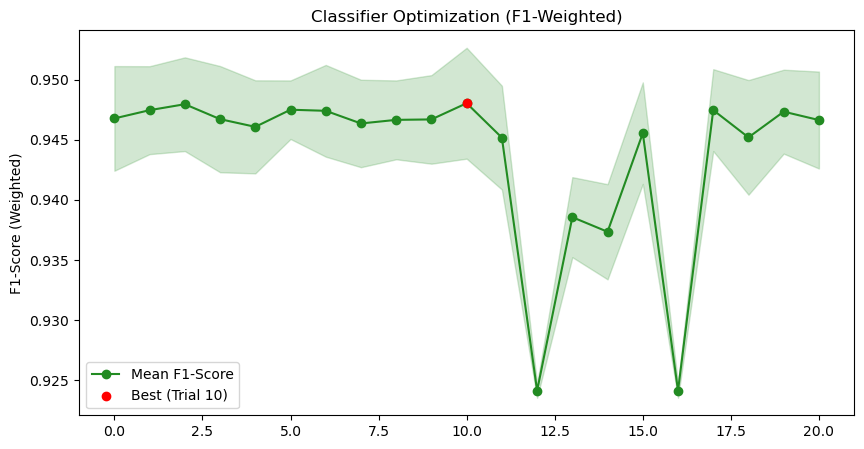

In [8]:
plot_classifier_performance(results_unweighted)

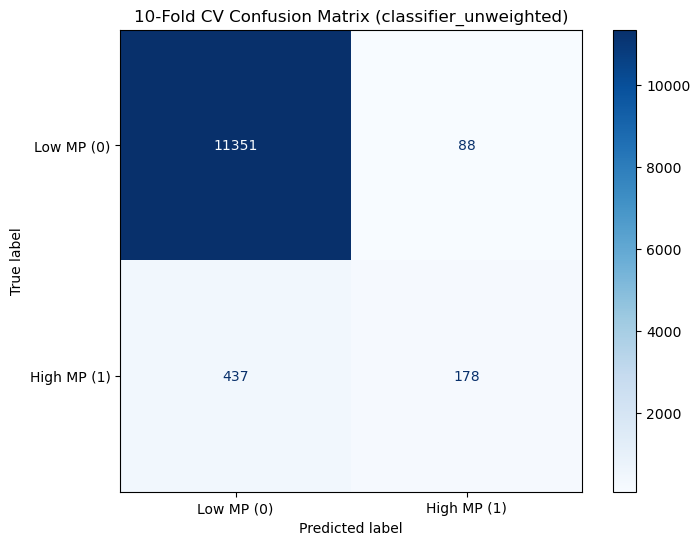

In [11]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate 'Out-of-Fold' predictions for the entire training set
# This uses the best hyperparameters found but ensures each prediction
# is made by a model that didn't see that specific data point during training.


label = 'MP_label'
output = 'Binary'
non_features = ['SMILES', 'MP', 'Type', label, output]
model_unweighted = joblib.load("best_model_LGB_classifier_unweighted.joblib")
model_type = "classifier_unweighted" # Changed from "weighted"
model_name = "LGB"
num_trials = 20

X = df_train.drop(columns=non_features)
y = df_train[output]

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
folds = list(skf.split(X, y))

y_pred_cv = cross_val_predict(model_unweighted, X, y, cv=folds)

# 2. Compute the matrix
cm = confusion_matrix(y, y_pred_cv)

# 3. Plot the matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low MP (0)', 'High MP (1)'])
disp.plot(cmap='Blues', ax=ax)
ax.set_title(f'10-Fold CV Confusion Matrix ({model_type})')
plt.show()

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1. Calculate individual metrics
accuracy  = accuracy_score(y, y_pred_cv)
precision = precision_score(y, y_pred_cv) # Focuses on 'High MP' (Class 1)
recall    = recall_score(y, y_pred_cv)    # Focuses on 'High MP' (Class 1)
f1        = f1_score(y, y_pred_cv)        # Harmonic mean of Precision/Recall

# 2. Print a clean summary
print(f"--- Performance Metrics: {model_type} Strategy ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (When model says 'High', how often is it right?)")
print(f"Recall:    {recall:.4f} (How many 'High' compounds did we catch?)")
print(f"F1-Score:  {f1:.4f}")
print("-" * 45)

# 3. Print the full report for both classes
print("Full Classification Report:")
print(classification_report(y, y_pred_cv, target_names=['Low MP', 'High MP']))

--- Performance Metrics: classifier_unweighted Strategy ---
Accuracy:  0.9564
Precision: 0.6692 (When model says 'High', how often is it right?)
Recall:    0.2894 (How many 'High' compounds did we catch?)
F1-Score:  0.4041
---------------------------------------------
Full Classification Report:
              precision    recall  f1-score   support

      Low MP       0.96      0.99      0.98     11439
     High MP       0.67      0.29      0.40       615

    accuracy                           0.96     12054
   macro avg       0.82      0.64      0.69     12054
weighted avg       0.95      0.96      0.95     12054



TEST SET EVALUATION

In [13]:
# Binary classifier
# data = combined, same as the regression model but with the binary label?
df = pd.read_parquet("../0_data/processed_data/data_with_selected_features_LGB_All_scaled_binary.parquet")
df_test = df[df['Type'] == 'Test'].reset_index(drop=True)

df_test

,SMILES,MP,Type,MP_label,RDKit_FpDensityMorgan3,RDKit_TPSA,RDKit_NumRotatableBonds,RDKit_SMR_VSA10,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_MRLOW,...,RDKit_Chi2n,RDKit_SlogP_VSA3,RDKit_fr_Ar_NH,RDKit_EState_VSA4,MACCS_89,RDKit_SMR_VSA9,MACCS_131,RDKit_fr_imidazole,RDKit_Chi0,Binary
0,C/C(=C\C(=N/Nc1ccc(cc1[N+](=O)[O-])[N+](=O)[O-...,115.0,Test,L,0.273579,1.654480,1.262156,0.802312,0.225087,-1.105193,...,0.667614,-0.775518,-0.20324,0.531278,-0.488331,-0.586923,-0.562084,-0.133569,1.401025,0
1,COC(=O)C(=C(SCc1ccccc1)SCc1ccccc1)C#N,104.0,Test,L,-0.835231,-0.048016,1.262156,0.846509,0.612333,-0.617962,...,0.304196,1.986153,-0.20324,0.023628,-0.488331,0.374209,-0.562084,-0.133569,0.908283,0
2,CC(=O)c1ccc(c(c1)F)O,128.0,Test,L,0.783228,-0.407457,-0.561777,-0.782647,-0.440110,-0.171672,...,-0.744034,-0.775518,-0.20324,0.107665,-0.488331,0.323579,-0.562084,-0.133569,-0.746893,0
3,NC(=O)C1=C(CCCC1)CCc1ccccc1,113.0,Test,L,0.465599,-0.244739,0.350190,-0.774131,0.168145,-0.578826,...,0.233292,0.696792,-0.20324,2.241899,-0.488331,-0.586923,-0.562084,-0.133569,-0.056709,0
4,OCCOc1ccccc1,12.0,Test,L,0.521953,-0.627787,0.046201,-1.180027,-0.902406,0.016888,...,-0.880423,-0.775518,-0.20324,-0.425651,-0.488331,0.323579,-0.562084,-0.133569,-0.972721,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5161,CN(CCNCc1cc(ccc1O)[N+](=O)[O-])C,158.5,Test,L,1.029135,0.754332,0.958167,-0.789234,-0.107671,-1.088784,...,-0.004857,0.083653,-0.20324,0.187604,-0.488331,0.323579,1.779092,-0.133569,0.084641,0
5162,C[Si](C#Cc1ccc(cc1)C#C[Si](C)(C)C)(C)C,120.0,Test,L,-2.139191,-1.455709,-0.865765,-0.070479,-0.999456,2.659783,...,1.017151,-0.775518,-0.20324,0.023628,-0.488331,3.044038,-0.562084,-0.133569,0.268670,0
5163,Brc1ccc(c(c1)C(F)(F)F)[N+](=O)[O-],34.0,Test,L,0.248235,-0.243334,-0.561777,0.305349,0.655692,-1.094674,...,-0.665594,0.035283,-0.20324,-0.399178,-0.488331,-0.586923,-0.562084,-0.133569,-0.275050,0
5164,OC(=O)C(C(=O)O)Cc1ccccc1,121.0,Test,L,-0.436059,0.640795,0.350190,-0.359698,-0.795887,-0.653368,...,-0.462402,1.326200,-0.20324,-0.906021,2.047792,-0.586923,1.779092,-0.133569,-0.346521,0


--- Final Test Results: classifier_unweighted Strategy ---
              precision    recall  f1-score   support

      Low MP       0.96      0.99      0.98      4903
     High MP       0.62      0.31      0.41       263

    accuracy                           0.96      5166
   macro avg       0.79      0.65      0.69      5166
weighted avg       0.95      0.96      0.95      5166

AUC-ROC: 0.9324


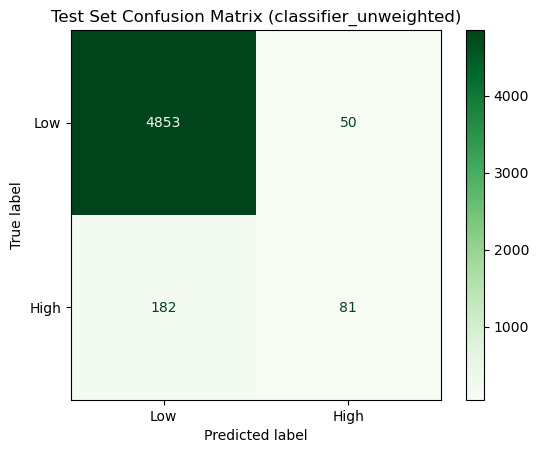

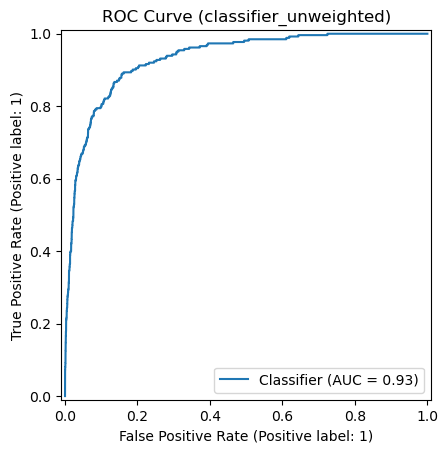

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

# 1. Prepare test features and labels
X_test = df_test.drop(columns=non_features)
y_test = df_test[output]

# 2. Predict
y_pred_test = model_unweighted.predict(X_test)
y_prob_test = model_unweighted.predict_proba(X_test)[:, 1]

# 3. Print classification report + AUC
print(f"--- Final Test Results: {model_type} Strategy ---")
print(classification_report(y_test, y_pred_test, target_names=['Low MP', 'High MP']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_test):.4f}")

# 4. Confusion matrix
cm_test = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Low', 'High'])
disp.plot(cmap='Greens')
plt.title(f'Test Set Confusion Matrix ({model_type})')
plt.show()

# 5. ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_test)
plt.title(f'ROC Curve ({model_type})')
plt.show()